In [1]:
import os
import random
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import cv2

from PIL import Image

from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
PROJECT_DIR = "/content/drive/MyDrive/computervisionproject"

DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "dataset",
    "processed_dataset"
)

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

print(DATASET_DIR)

/content/drive/MyDrive/computervisionproject/dataset/processed_dataset


In [4]:
assert os.path.exists(TRAIN_DIR)
assert os.path.exists(VAL_DIR)
assert os.path.exists(TEST_DIR)

print("Dataset verified successfully.")

Dataset verified successfully.


In [5]:
def count_images(folder):

    counts = {}

    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)

        counts[cls] = len(os.listdir(cls_path))

    return counts


train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

print("Training")

print(train_counts)

print()

print("Validation")

print(val_counts)

print()

print("Testing")

print(test_counts)

Training
{'COVID': 2892, 'Normal': 2881, 'Viral Pneumonia': 1076}

Validation
{'COVID': 361, 'Viral Pneumonia': 134}

Testing
{'COVID': 363, 'Viral Pneumonia': 135}


In [6]:
stats = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
})

stats["Total"] = stats.sum(axis=1)

stats

,Train,Validation,Test,Total
COVID,2892,361.0,363.0,3616.0
Normal,2881,NaN,NaN,2881.0
Viral Pneumonia,1076,134.0,135.0,1345.0


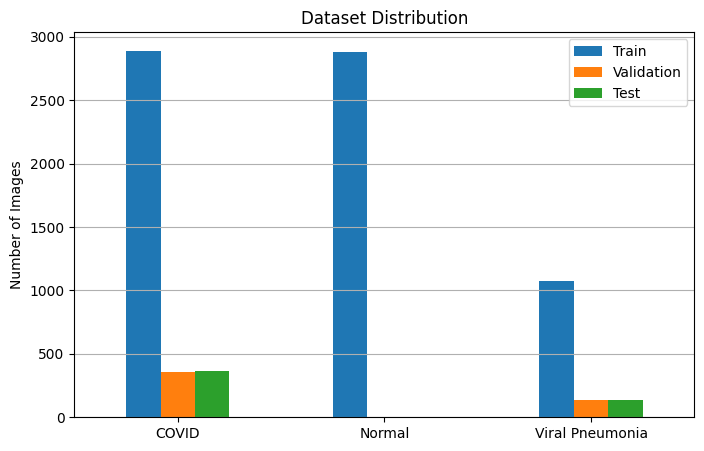

In [7]:
stats[["Train", "Validation", "Test"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Dataset Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

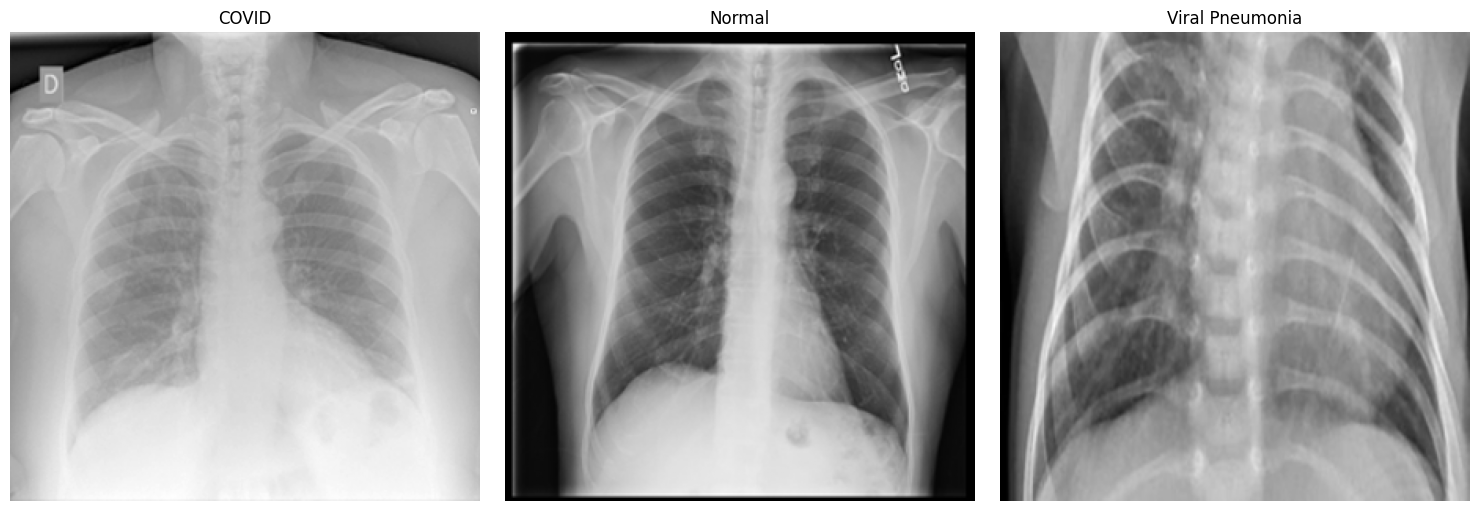

In [8]:
classes = sorted(os.listdir(TRAIN_DIR))

plt.figure(figsize=(15,5))

for i, cls in enumerate(classes):

    image_name = random.choice(
        os.listdir(
            os.path.join(TRAIN_DIR, cls)
        )
    )

    img_path = os.path.join(
        TRAIN_DIR,
        cls,
        image_name
    )

    img = Image.open(img_path)

    plt.subplot(1,3,i+1)

    plt.imshow(img, cmap="gray")

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [9]:
dimensions = []

for cls in classes:

    folder = os.path.join(TRAIN_DIR, cls)

    for img_name in os.listdir(folder):

        img = Image.open(
            os.path.join(folder, img_name)
        )

        dimensions.append(img.size)

dimensions = np.array(dimensions)

print("Unique Widths :", len(np.unique(dimensions[:,0])))
print("Unique Heights:", len(np.unique(dimensions[:,1])))

print()

print("Example dimensions:")

print(dimensions[:10])

Unique Widths : 1
Unique Heights: 1

Example dimensions:
[[299 299]
 [299 299]
 [299 299]
 [299 299]
 [299 299]
 [299 299]
 [299 299]
 [299 299]
 [299 299]
 [299 299]]


In [10]:
bad_images = []

for cls in classes:

    folder = os.path.join(TRAIN_DIR, cls)

    for img_name in os.listdir(folder):

        path = os.path.join(folder, img_name)

        try:

            img = Image.open(path)

            img.verify()

        except:

            bad_images.append(path)

print("Corrupted Images:", len(bad_images))

Corrupted Images: 0


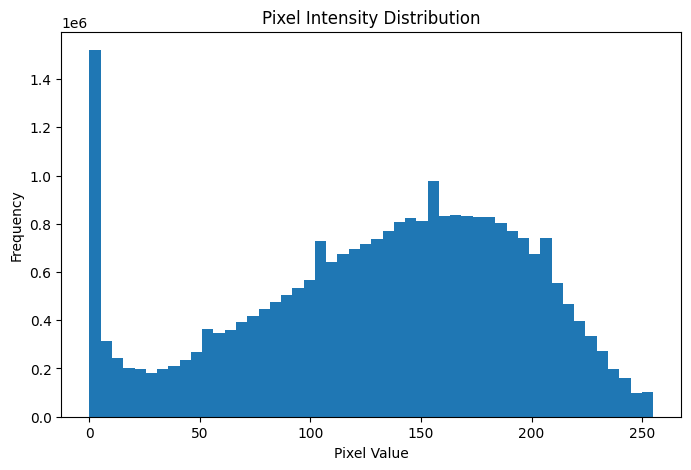

In [11]:
pixels = []

for cls in classes:

    folder = os.path.join(TRAIN_DIR, cls)

    sample_images = random.sample(
        os.listdir(folder),
        100
    )

    for img_name in sample_images:

        img = cv2.imread(
            os.path.join(folder,img_name),
            cv2.IMREAD_GRAYSCALE
        )

        pixels.extend(img.flatten())

plt.figure(figsize=(8,5))

plt.hist(
    pixels,
    bins=50
)

plt.title("Pixel Intensity Distribution")

plt.xlabel("Pixel Value")

plt.ylabel("Frequency")

plt.show()

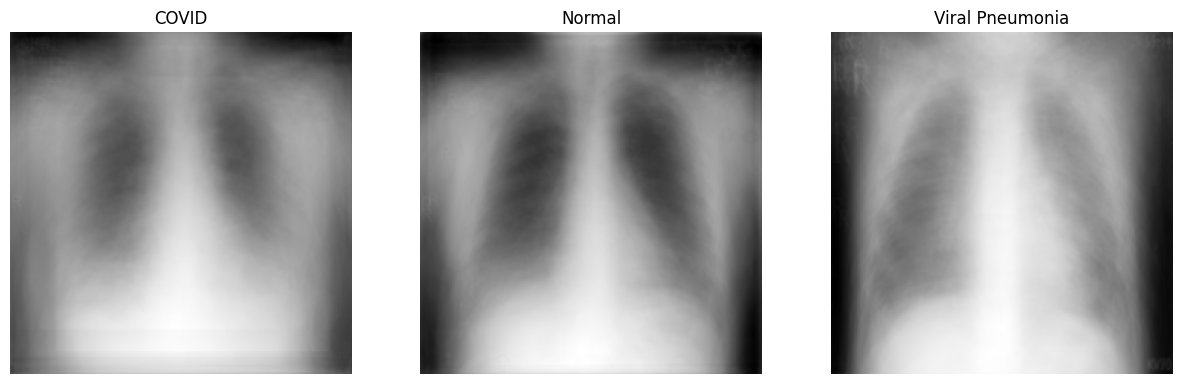

In [12]:
plt.figure(figsize=(15,5))

for idx, cls in enumerate(classes):

    folder = os.path.join(TRAIN_DIR, cls)

    images = []

    sample = random.sample(
        os.listdir(folder),
        50
    )

    for img_name in sample:

        img = cv2.imread(
            os.path.join(folder,img_name),
            cv2.IMREAD_GRAYSCALE
        )

        img = cv2.resize(img,(224,224))

        images.append(img)

    mean_img = np.mean(images, axis=0)

    plt.subplot(1,3,idx+1)

    plt.imshow(mean_img, cmap="gray")

    plt.title(cls)

    plt.axis("off")

plt.show()

In [13]:
REPORT_DIR = os.path.join(
    PROJECT_DIR,
    "reports"
)

os.makedirs(REPORT_DIR, exist_ok=True)

stats.to_csv(
    os.path.join(
        REPORT_DIR,
        "dataset_statistics.csv"
    )
)

print("Dataset statistics saved.")

Dataset statistics saved.


In [14]:
print("="*60)

print("DATASET ANALYSIS COMPLETED")

print("="*60)

print(f"Classes          : {len(classes)}")

print(f"Training Images  : {sum(train_counts.values())}")

print(f"Validation Images: {sum(val_counts.values())}")

print(f"Testing Images   : {sum(test_counts.values())}")

print("="*60)

DATASET ANALYSIS COMPLETED
Classes          : 3
Training Images  : 6849
Validation Images: 495
Testing Images   : 498
